# **Rainfall Projections over the Western Ghats under SSP245**
### CMIP6 EC-Earth3 Analysis (2025–2100)

HOTOSM Mentorship Legacy Project  
Author: Shachi  


##  Introduction

The Western Ghats is a critical orographic region influencing monsoon rainfall over India.
Understanding future precipitation changes under climate change scenarios is essential for
water resources, biodiversity and disaster risk planning.

This study analyzes projected rainfall from the EC-Earth3 CMIP6 model under the SSP245 scenario
for the period 2025–2100, focusing on spatial and temporal variability across northern, central
and southern Western Ghats.


## Data Description

This study uses projected precipitation data from the Coupled Model Intercomparison Project Phase 6 (CMIP6), accessed through the NASA Earth Exchange Global Daily Downscaled Projections (NEX-GDDP-CMIP6) dataset.

CMIP6 provides standardized global climate simulations under different future greenhouse gas emission and socioeconomic pathways. The NEX-GDDP-CMIP6 archive offers statistically downscaled and bias-corrected CMIP6 outputs at a spatial resolution of 0.25° × 0.25° (~25 km), making them suitable for regional climate impact analysis.

Daily precipitation ('pr') data from the EC-Earth3 climate model were downloaded for the SSP245 scenario, which represents a moderate, middle-of-the-road emissions pathway.

- Variable: Daily precipitation rate (`pr`, kg m⁻² s⁻¹), converted to mm/day  
- Time period: 2025–2100  
- Spatial domain: Western Ghats region, India
- bbox (roughly encompassing western ghats)

The data were spatially filtered to retain only grid points located within the Western Ghats boundary and further divided into North, Central, and South Western Ghats to enable sub-regional analysis.


In [ ]:
# Installation of important librares and data download
!pip -q install xarray netCDF4 regionmask geopandas shapely cartopy
from google.colab import drive
drive.mount('/content/drive')

import re, requests, os, time
from urllib.parse import quote
import xarray as xr
import numpy as np
import netCDF4 as nc

models = ("EC-Earth3",)


var   = "pr"
run   = "r1i1p1f1"  # Default run - script will try alternatives if this doesn't work
scenario = "ssp245"  # SSP245 scenario only
years_future = range(2025, 2101)  # 2025–2065 for SSP245

# Updated coordinates
N, S, E, W = 21, 8, 79, 73

# ==== BASE PATHS ====
BASE_CAT  = "https://ds.nccs.nasa.gov/thredds/catalog/AMES/NEX/GDDP-CMIP6"
BASE_NCSS = "https://ds.nccs.nasa.gov/thredds/ncss/grid/AMES/NEX/GDDP-CMIP6"

# ==== GOOGLE DRIVE FOLDER CONFIGURATION ====
# Updated folder ID from: https://drive.google.com/drive/folders/19rgAccxue3rMSCdm9Zeq5cenxYVKI67V
MAIN_SAVE_PATH = "/content/drive/MyDrive/CMIP6_WesternGhats_EC-Earth3_SSP245"
os.makedirs(MAIN_SAVE_PATH, exist_ok=True)

# ==== COMMON RUNS TO TRY FOR DIFFERENT MODELS ====
COMMON_RUNS = [
    "r1i1p1f1", "r2i1p1f1", "r3i1p1f1", "r4i1p1f1", "r5i1p1f1",
    "r1i1p1f2", "r1i1p1f3", "r1i2p1f1", "r1i3p1f1"
]


def find_available_run(model, scenario):
    """Finding the first available run for a given model and scenario"""
    print(f"Searching for available runs for {model} in {scenario}...")

    # First trying the specified run
    if check_model_has_scenario_data(model, run, scenario):
        print(f" Using specified run: {run}")
        return run

    # Trying common runs
    for test_run in COMMON_RUNS:
        if check_model_has_scenario_data(model, test_run, scenario):
            print(f"Found available run: {test_run}")
            return test_run

    print(f"No available runs found for {model} in {scenario}")
    return None

def check_model_has_scenario_data(model, run, scenario):
    """Checking if a model has data for specific scenario with specific run"""
    try:
        scenario_url = f"{BASE_CAT}/{model}/{scenario}/{run}/catalog.html"
        response = requests.get(scenario_url, timeout=30)
        return response.status_code == 200
    except:
        return False

def list_available_models():
    """Listing some common CMIP6 models available in NEX-GDDP-CMIP6"""
    common_models = [
        "ACCESS-CM2", "ACCESS-ESM1-5", "BCC-CSM2-MR", "CESM2", "CESM2-WACCM",
        "CMCC-CM2-SR5", "CMCC-ESM2", "CNRM-CM6-1", "CNRM-ESM2-1", "CanESM5",
        "EC-Earth3", "EC-Earth3-Veg", "FGOALS-g3", "GFDL-CM4", "GFDL-ESM4",
        "GISS-E2-1-G", "HadGEM3-GC31-LL", "HadGEM3-GC31-MM", "IITM-ESM",
        "INM-CM4-8", "INM-CM5-0", "IPSL-CM6A-LR", "KACE-1-0-G", "KIOST-ESM",
        "MIROC-ES2L", "MIROC6", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "MRI-ESM2-0",
        "NESM3", "NorESM2-LM", "NorESM2-MM", "TaiESM1", "UKESM1-0-LL"
    ]
    return common_models

def _list_year_files(model, run, var, scenario, year):
    """Listing available files for a specific year"""
    cat_url = f"{BASE_CAT}/{model}/{scenario}/{run}/{var}/catalog.html"

    try:
        print(f"Catalog URL: {cat_url}")
        html = requests.get(cat_url, timeout=60).text

        pat = re.compile(
            rf"{var}_day_{re.escape(model)}_{scenario}_{re.escape(run)}_gr_{year}_v2\.0\.nc"
        )

        return sorted(set(pat.findall(html)))

    except Exception as e:
        print(f"Error listing files for {model} {year}: {e}")
        return []


def _prefer_best_filename(filenames):
    """Prefer the best version of available files"""
    if not filenames:
        return None
    for suffix in ["_v2.0.nc"]:

        for f in filenames:
            if f.endswith(suffix):
                return f

    return filenames[0]

def build_ncss_url(model, run, var, scenario, year, N, S, E, W):
    """Build NetCDF Subset Service URL"""
    fname = _prefer_best_filename(_list_year_files(model, run, var, scenario, year))
    if fname is None:
        return None
    path = f"{BASE_NCSS}/{model}/{scenario}/{run}/{var}/{quote(fname)}"
    return (f"{path}?var={var}&north={N}&south={S}&east={E}&west={W}"
            f"&horizStride=1&time_start={year}-01-01T00:00:00Z"
            f"&time_end={year}-12-31T00:00:00Z&accept=netcdf4&addLatLon=true")

def download_file(url, filename):
    """Download a file with progress indication"""
    if url is None:
        print("No file for this year.")
        return False

    try:
        print(f"Downloading: {os.path.basename(filename)}")
        r = requests.get(url, stream=True, timeout=300)
        r.raise_for_status()

        total_size = int(r.headers.get('content-length', 0))
        downloaded = 0

        with open(filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):  # 1MB chunks
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    # Progress indication every 10MB
                    if total_size > 0 and downloaded % (1024*1024*10) == 0:
                        progress = (downloaded / total_size) * 100
                        print(f"  Progress: {progress:.1f}%")

        file_size_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"Downloaded {os.path.basename(filename)} ({file_size_mb:.1f}MB)")
        return True

    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return False

def process_model_bbox_only(model, used_run, scenario):
    """Process all years for a model - BBOX files only"""
    print(f"\nProcessing model: {model} with run: {used_run} for scenario: {scenario}")
    print("=" * 70)

    # Create model-specific directory for BBOX files only
    model_bbox_dir = f"{MAIN_SAVE_PATH}/{model}_{used_run}_{scenario}"
    os.makedirs(model_bbox_dir, exist_ok=True)
    print(f"BBOX files will be saved to: {model_bbox_dir}")

    success_count = 0
    total_years = len(years_future)

    # Downloading bbox files for each year
    print(f"Downloading years {min(years_future)}-{max(years_future)} for {model} ({used_run}) - {scenario}")

    for i, year in enumerate(years_future, 1):
        print(f"\n[{i}/{total_years}] Processing year {year}")

        url = build_ncss_url(model, used_run, var, scenario, year, N, S, E, W)
        fp_bbox = f"{model_bbox_dir}/{var}_{model}_{used_run}_{scenario}_{year}.nc"

        # Skip if file already exists
        if os.path.exists(fp_bbox):
            print(f" File already exists: {os.path.basename(fp_bbox)}")
            success_count += 1
            continue

        if download_file(url, fp_bbox):
            success_count += 1

            # Print file version for verification
            try:
                with nc.Dataset(fp_bbox, 'r') as ds_nc:
                    version = getattr(ds_nc, "version", "unknown")
                    print(f"    File version: {version}")
            except:
                pass

        # Small delay between downloads
        if i < total_years:
            print(" Waiting 2 seconds...")
            time.sleep(2)

    print(f"\n {model} {scenario} BBOX download summary: {success_count}/{total_years} files successful")
    return success_count

def main(model):
    """Main execution function - SSP245 BBOX only"""
    print("\n SSP245 BBOX Climate Data Downloader")
    print("=" * 70)
    print(f" Target Model: {model}")
    print(f" Period: SSP245 scenario {min(years_future)}-{max(years_future)}")
    print(f" Coordinates: N:{N}°, S:{S}°, E:{E}°, W:{W}°")
    print(f" Variable: {var} (precipitation)")
    print(f" Scenario: {scenario} only")
    print(f" Output: BBOX files only ")
    print("=" * 70)

    #global MAIN_SAVE_PATH
    #MAIN_SAVE_PATH = get_folder_path_by_id(GDRIVE_FOLDER_ID)

    # Find available run
    available_run = find_available_run(model, scenario)
    if not available_run:
        print(f" No data available for {model} in {scenario}")
        return

    try:
        bbox_success = process_model_bbox_only(model, available_run, scenario)
        print(f" {model} {scenario} completed - BBOX files: {bbox_success}")
    except Exception as e:
        print(f" Error processing {model} {scenario}: {e}")
        return

    # Final summary
    print(f"\n {model.upper()} SSP245 BBOX DOWNLOAD COMPLETED!")
    print("=" * 70)
    print(f" Final Statistics:")
    print(f"  Model: {model}")
    print(f"  Run used: {available_run}")
    print(f"  Scenario: {scenario}")
    print(f"  BBOX files downloaded: {bbox_success}")
    print(f"  Years: {len(years_future)} ({min(years_future)}-{max(years_future)})")
    print(f"  Coordinates: N:{N}°, S:{S}°, E:{E}°, W:{W}°")
    print(f" Data saved in: {MAIN_SAVE_PATH}")
    print(f" Folder created: {model}_{available_run}_{scenario}_BBOX")
    print(f" Files saved as: {var}_{model}_{available_run}_{scenario}_YYYY_bbox.nc")

# EXECUTE THE DOWNLOAD NOW
print(" Starting SSP245 Climate Data Download...")
for mod in models:
    main(mod)

print("\n All requested models processed!")

In [ ]:
import os

BASE = "/content/drive/MyDrive"

for root, dirs, files in os.walk(BASE):
    for d in dirs:
        if "EC-Earth3" in d or "CMIP6" in d:
            print(os.path.join(root, d))


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [ ]:
import xarray as xr
import pandas as pd
import geopandas as gpd
import os

## Data Processing

Daily precipitation data have been downloaded in NetCDF format for the period 2025–2100. The raw precipitation variable is provided as a precipitation rate in units of kg ms⁻¹. Each NetCDF file corresponds to a single year of daily data.
Next steps:
- NetCDF to CSV Conversion
- Unit Conversion(mm/day)





In [ ]:
# NetCDF to csv conversion

DATA_DIR = "/content/drive/MyDrive/CMIP6_WesternGhats_EC-Earth3_SSP245/EC-Earth3_r1i1p1f1_ssp245"
OUTPUT_CSV = "/content/drive/MyDrive/EC-Earth3_SSP245_WesternGhats_pr_2025_2100.csv"

dfs = []

nc_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if f.endswith(".nc")
])

print(f"Found {len(nc_files)} NetCDF files")

for file in nc_files:
    path = os.path.join(DATA_DIR, file)
    print(f"Processing {file}")

    ds = xr.open_dataset(path)

    # Converting precipitation to DataFrame
    df = ds["pr"].to_dataframe().reset_index()

    # Converting units: kg m-2 s-1 → mm/day
    df["pr_mm_day"] = df["pr"] * 86400

    # only required columns
    df = df[["time", "lat", "lon", "pr_mm_day"]]

    dfs.append(df)

    ds.close()

# Combining all years
final_df = pd.concat(dfs, ignore_index=True)

# Save combined CSV
final_df.to_csv(OUTPUT_CSV, index=False)

print(" Combined CSV saved at:")
print(OUTPUT_CSV)
print(final_df.head())


Found 76 NetCDF files
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2025.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2026.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2027.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2028.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2029.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2030.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2031.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2032.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2033.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2034.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2035.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2036.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2037.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2038.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2039.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2040.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2041.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2042.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2043.nc
Processing pr_EC-Earth3_r1i1p1f1_ssp245_2044.nc
Processing pr_EC-E

In [ ]:


CSV_PATH = "/content/drive/MyDrive/EC-Earth3_SSP245_WesternGhats_pr_2025_2100.csv"

pr_df = pd.read_csv(CSV_PATH)


In [ ]:

pr_df.head()



,time,lat,lon,pr_mm_day
0,2025-01-01 12:00:00,8.125,73.125,NaN
1,2025-01-01 12:00:00,8.125,73.375,NaN
2,2025-01-01 12:00:00,8.125,73.625,NaN
3,2025-01-01 12:00:00,8.125,73.875,NaN
4,2025-01-01 12:00:00,8.125,74.125,NaN


In [ ]:
pr_df.tail()

,time,lat,lon,pr_mm_day
36779345,2100-12-31 12:00:00,21.125,78.125,0.0
36779346,2100-12-31 12:00:00,21.125,78.375,0.0
36779347,2100-12-31 12:00:00,21.125,78.625,0.0
36779348,2100-12-31 12:00:00,21.125,78.875,0.0
36779349,2100-12-31 12:00:00,21.125,79.125,0.0


In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)


In [ ]:
gdf.head()

,time,lat,lon,pr_mm_day,geometry
0,2025-01-01 12:00:00,8.125,73.125,NaN,POINT (73.125 8.125)
1,2025-01-01 12:00:00,8.125,73.375,NaN,POINT (73.375 8.125)
2,2025-01-01 12:00:00,8.125,73.625,NaN,POINT (73.625 8.125)
3,2025-01-01 12:00:00,8.125,73.875,NaN,POINT (73.875 8.125)
4,2025-01-01 12:00:00,8.125,74.125,NaN,POINT (74.125 8.125)


In [ ]:
wg = gpd.read_file("western_ghats_A.geojson").to_crs(epsg=4326)
gdf_wg = gpd.sjoin(gdf, wg, predicate="within")


In [ ]:
# loading Western Ghats Boundary data

wg = gpd.read_file(r"/content/drive/MyDrive/western_Ghats_Boundary.geojson").to_crs(epsg=4326)





In [ ]:
wg.head()


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,geometry
0,None,Western Ghats Border,None,None,None,None,None,-1,0,-1,None,None,"MULTIPOLYGON (((76.11506 12.20915, 76.12164 12..."


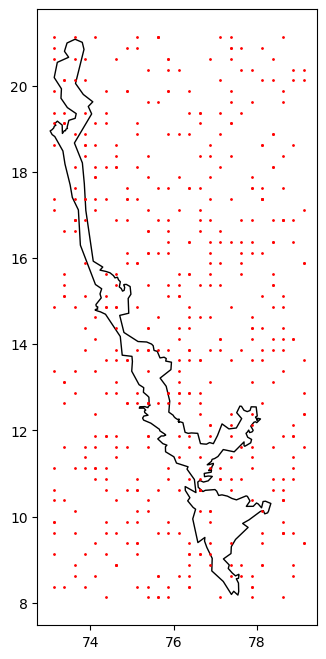

In [ ]:
# plotting cmip6 data points  bbox around the western ghats
import matplotlib.pyplot as plt

ax = wg.plot(edgecolor="black", facecolor="none", figsize=(6,8))
gdf.sample(500).plot(ax=ax, color="red", markersize=1)
plt.show()
